In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import numpy as np
import optax

from flax import nnx
from functools import partial
from jax_tqdm import loop_tqdm
from tqdm.notebook import tqdm
from typing import Any, NamedTuple

from src.decoding import make_autoregressive
from src.models.gpt import InContextGPTWithThoughts
from src.models.next_token import TokenEmbedders
from src.models.nope import NoPE
from src.models import TrainState

In [3]:
class LatentStepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    rng: chex.PRNGKey
    observations: chex.Array
    thoughts: chex.Array
    last_prompt_idx: int


def predict_latent_step(
    step_i: int,
    step_state: LatentStepState,
):
    rng, rng_step = jax.random.split(step_state.rng, 2)

    is_prompt = step_i < step_state.last_prompt_idx

    # Autoregressively decode
    module = nnx.merge(step_state.graphdef, step_state.cache, step_state.rest)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)

    embed = step_state.thoughts[:, [step_i]]

    logits = module.latent_thought_step(embed)
    cache = nnx.state(module, nnx.Cache)

    thought = logits[:, 0]

    # Check for prompt boundary
    thought = jnp.where(
        is_prompt[:, None],
        module.get_embedding(
            step_state.observations[:, step_i + 1]
        ),
        thought,
    )

    # Update the entries on the i'th step
    thoughts = step_state.thoughts.at[:, step_i + 1].set(thought)

    step_state = LatentStepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        rng=rng,
        observations=step_state.observations,
        thoughts=thoughts,
        last_prompt_idx=step_state.last_prompt_idx,
    )

    return step_state

In [4]:
class StepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    eos_token: int
    rng: chex.PRNGKey
    embed_seq: chex.Array
    logits: chex.Array
    actions: chex.Array
    last_thought_idx: int
    eos: chex.Array
    deterministic: int = 0


def predict_step(
    step_i: int,
    step_state: StepState,
):
    rng, rng_step = jax.random.split(step_state.rng, 2)

    # Autoregressively decode
    module = nnx.merge(step_state.graphdef, step_state.rest, step_state.cache)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)
    logits = module.output_step(step_state.embed_seq[:, [step_i]])
    cache = nnx.state(module, nnx.Cache)

    logits = logits[:, 0]

    # Actual action taken, but output_tokens can be different
    action = jax.lax.cond(
        step_state.deterministic,
        lambda rng_step, logits: jnp.argmax(logits, axis=-1),
        jax.random.categorical,
        rng_step,
        logits,
    )

    action_embed = jax.lax.stop_gradient(module.get_embedding(action))

    is_thought = step_i < step_state.last_thought_idx

    # Check for prompt boundary
    action_embed = jnp.where(
        is_thought[:, None],
        step_state.embed_seq[:, step_i + 1],
        action_embed,
    )

    # Check if the first EOS has been generated
    eos = jnp.select(
        is_thought,
        jnp.zeros_like(is_thought),
        jnp.logical_or(
            action == step_state.eos_token,
            step_state.eos[:, step_i],
        )
    )

    # Update the entries on the i'th step
    embed_seq = step_state.embed_seq.at[:, step_i + 1].set(action_embed)
    actions = step_state.actions.at[:, step_i + 1].set(action)
    logits = step_state.logits.at[:, step_i + 1].set(logits)
    eos = step_state.eos.at[:, step_i + 1].set(eos)

    step_state = StepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        eos_token=step_state.eos_token,
        rng=rng,
        embed_seq=embed_seq,
        actions=actions,
        last_thought_idx=step_state.last_thought_idx,
        eos=eos,
        deterministic=step_state.deterministic,
        logits=logits,
    )

    return step_state

In [5]:
num_blocks = 2
num_heads = 2
embed_dim = 8
widening_factor = 4
dtype = jnp.float32
eos_token = 3

num_input_tokens = 4
num_output_tokens = 2

lr = 1e-3
max_iter = 100000

rngs = nnx.Rngs(42)
rollout_rng = jrandom.PRNGKey(42)

model = InContextGPTWithThoughts(
    num_blocks,
    num_heads,
    embed_dim,
    widening_factor,
    partial(
        TokenEmbedders,
        num_input_tokens=num_input_tokens,
        num_output_tokens=num_output_tokens,
        embed_dim=embed_dim,
        rngs=rngs,
        shared_decoding=True,
        decode=False,
        dtype=dtype,
    ),
    partial(NoPE),
    rngs,
)

graphdef, params, rest = nnx.split(model, nnx.Param, ...)
opt = optax.adam(lr)

train_state = TrainState.create(
    apply_fn=graphdef.apply,
    params=params,
    tx=opt,
    graphdef=graphdef,
    rest=rest,
)

In [6]:
def complexity_fn(last_prompt_idx):
    return last_prompt_idx + 1

In [7]:
def match_action(action, answer, answer_len):
    match_mask = jnp.zeros(len(action))
    match_mask = match_mask.at[answer_len].set(1)
    match_mask = jnp.cumsum(match_mask)
    return {
        "success": jnp.all((action == answer) * (1 - match_mask) + match_mask).astype(int),
        "mask": 1 - match_mask,
    }


In [8]:
num_questions = 1
rollout_samples = 4
batch_size = int(rollout_samples * num_questions)
max_input_len = 5
max_thought_len = max_input_len
max_output_len = 4

think_phase_len = max_thought_len + max_input_len
output_phase_len = max_thought_len + max_input_len + max_output_len

questions = jnp.array([
    [0, 1, 2, 3, 3],
    # [1, 2, 3, 3, 3],
])
answer = jnp.array([
    [0, 1, 3, 3],
    # [1, 3, 3, 3],
])
last_prompt_idx = jnp.array([
    2,
    # 1,
])
last_thought_idx = last_prompt_idx + complexity_fn(last_prompt_idx)
answer_len = jnp.array([
    2,
    # 1,
])

questions = jnp.repeat(
    questions,
    rollout_samples,
    axis=0,
)
answer = jnp.repeat(
    answer,
    rollout_samples,
    axis=0,
)
last_prompt_idx = jnp.repeat(
    last_prompt_idx,
    rollout_samples,
    axis=0,
)
last_thought_idx = jnp.repeat(
    last_thought_idx,
    rollout_samples,
    axis=0,
)
answer_len = jnp.repeat(
    answer_len,
    rollout_samples,
    axis=0,
)

questions = jax.device_put(questions)
answer = jax.device_put(answer)
last_prompt_idx = jax.device_put(last_prompt_idx)
last_thought_idx = jax.device_put(last_thought_idx)
answer_len = jax.device_put(answer_len)

In [9]:
@jax.jit
@partial(jax.value_and_grad, has_aux=True)
def compute_loss(params, rollout_rng):
    # Get initial cache
    module = nnx.merge(train_state.graphdef, params, train_state.rest)
    _, init_cache = make_autoregressive(
        module,
        max_decode_len=max_thought_len + max_input_len,
        batch_size=batch_size,
        embed_dim=embed_dim,
        dtype=dtype,
        eval_mode=True,
    )
    cache = init_cache()
    graphdef, _, rest = nnx.split(module, nnx.Cache, ...)

    thoughts = jnp.zeros((batch_size, think_phase_len, embed_dim))
    thoughts = thoughts.at[:, 0].set(module.get_embedding(questions[:, 0]))
    thought_step_state = LatentStepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        rng=rollout_rng,
        observations=questions,
        thoughts=thoughts,
        last_prompt_idx=last_prompt_idx,
    )

    thought_step_state = jax.lax.fori_loop(
        0,
        think_phase_len,
        predict_latent_step,
        thought_step_state,
    )

    embed_seq = jnp.empty((batch_size, output_phase_len, embed_dim))
    embed_seq = embed_seq.at[:, :think_phase_len].set(thought_step_state.thoughts)
    actions = jnp.zeros((batch_size, output_phase_len), dtype=int)

    step_state = StepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        eos_token=eos_token,
        rng=rollout_rng,
        embed_seq=embed_seq,
        actions=actions,
        last_thought_idx=last_thought_idx,
        eos=jnp.zeros((batch_size, output_phase_len)),
        deterministic=False,
        logits=jnp.zeros((batch_size, output_phase_len, num_output_tokens))
    )

    step_state = jax.lax.fori_loop(
        0,
        output_phase_len,
        predict_step,
        step_state,
    )

    actions = jax.vmap(
        partial(
            jax.lax.dynamic_slice_in_dim,
            axis=0,
            slice_size=max_output_len,
        )
    )(
        operand=step_state.actions,
        start_index=last_thought_idx + 1,
    )

    # rewards = jnp.all(actions == answer, axis=-1)
    res = jax.vmap(match_action)(actions, answer, answer_len)
    match_mask = res["mask"]
    success = res["success"]
    rewards = jnp.tile(success, reps=(max_output_len, 1)).T.reshape(-1)

    actions = actions.reshape(-1)

    logits = jax.vmap(
        partial(
            jax.lax.dynamic_slice_in_dim,
            axis=0,
            slice_size=max_output_len,
        )
    )(
        operand=step_state.logits,
        start_index=last_thought_idx + 1,
    )
    logits = logits.reshape(len(actions), -1)

    lprobs = jnp.sum(
        logits, axis=-1, where=actions[:, None],
    ) - jax.nn.logsumexp(logits, axis=-1)

    return -jnp.mean(lprobs * rewards, where=match_mask.reshape(-1)), {
        "actions": actions,
        "success": success,
        "logits": logits,
        "match_mask": match_mask,
    }

In [10]:
class LogStepState(NamedTuple):
    train_state: TrainState
    losses: chex.Array
    successes: chex.Array
    entropies: chex.Array

@loop_tqdm(max_iter)
def train_step(
    step_i: int,
    step_state: LogStepState,
):
    train_state = step_state.train_state
    (loss, aux), grads = compute_loss(train_state.params, jrandom.fold_in(rollout_rng, step_i))
    train_state = train_state.apply_gradients(grads=grads)

    success_rate = jnp.mean(aux["success"])
    losses = step_state.losses.at[step_i].set(loss)
    successes = step_state.successes.at[step_i].set(success_rate)

    match_mask = aux["match_mask"]
    logits = aux["logits"].reshape((batch_size, max_output_len, -1))
    probs = jax.nn.softmax(logits, axis=-1)
    entropies = optax.softmax_cross_entropy(logits, probs)
    entropies = jnp.mean(entropies, where=match_mask)
    entropies = step_state.entropies.at[step_i].set(entropies)

    return LogStepState(
        train_state,
        losses,
        successes,
        entropies,
    )

In [ ]:
logs = jax.lax.fori_loop(
    0,
    max_iter,
    train_step,
    LogStepState(
        train_state,
        jnp.zeros(max_iter),
        jnp.zeros(max_iter),
        jnp.zeros(max_iter),
    )
)

In [ ]:
def smooth_lists(iterations, lists, N):
    smoothed_lists = []
    for curr_list in lists:
        curr_list = np.array(curr_list)
        smoothed = np.convolve(curr_list, np.ones(N)/N, mode='valid')
        smoothed_lists.append(smoothed)
    iterations = np.array(iterations)
    smoothed_iter = iterations[N-1:]
    
    return smoothed_iter, smoothed_lists

In [ ]:
smooth_window = 1000
smoothed_iter, smoothed_res = smooth_lists(
    np.arange(len(logs.losses)),
    [
        logs.losses,
        logs.successes,
        logs.entropies,
    ],
    smooth_window,
)

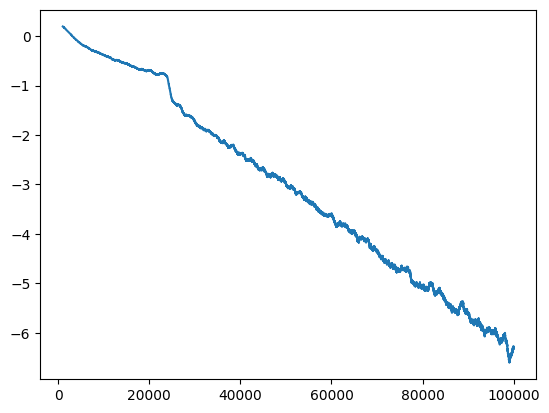

In [ ]:
plt.plot(smoothed_iter, smoothed_res[0])

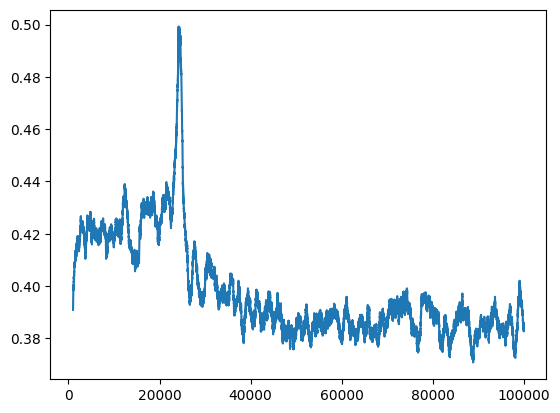

In [ ]:
plt.plot(smoothed_iter, smoothed_res[1])

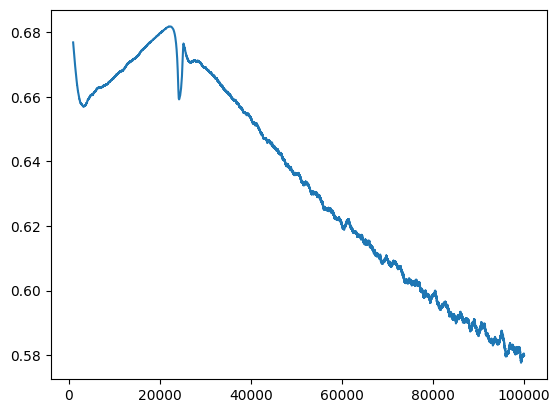

In [ ]:
plt.plot(smoothed_iter, smoothed_res[2])